---
## Part 1: Comparing Backends (10 points)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} | Device: {device}')

PyTorch 2.10.0+cu128 | Device: cuda


In [2]:
class SimpleNet(nn.Module):
    def __init__(self, dim=1024):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(dim, dim), nn.ReLU(),
            nn.Linear(dim, dim), nn.ReLU(),
            nn.Linear(dim, dim),
        )
    def forward(self, x): return self.layers(x)

In [3]:
def sync():
    if device == 'cuda':
        torch.cuda.synchronize()
def benchmark(fn, x, n_runs=100, warmup=10, is_cudagraphs=False):
    px = x.clone().detach().requires_grad_(True)
    def step():
        if is_cudagraphs:
            px.data.copy_(x)
            fn(px)
        else:
            out = fn(x.clone().detach().requires_grad_(True))
            out.sum().backward()
    for _ in range(warmup):
        torch.compiler.cudagraph_mark_step_begin(); step()
    sync()
    times = []
    for _ in range(n_runs):
        torch.compiler.cudagraph_mark_step_begin()
        sync(); t0 = time.perf_counter()
        step()
        sync(); times.append((time.perf_counter() - t0) * 1000)
    return np.mean(times), np.std(times)

eager         2.662 ± 2.222 ms
aot_eager     2.686 ± 1.734 ms
inductor      2.459 ± 0.821 ms


/usr/local/lib/python3.12/dist-packages/torch/cuda/graphs.py:130: UserWarning: The CUDA Graph is empty. This usually means that the graph was attempted to be captured on wrong device or stream. (Triggered internally at /pytorch/aten/src/ATen/cuda/CUDAGraph.cpp:139.)
  super().capture_end()


cudagraphs    1.468 ± 0.906 ms


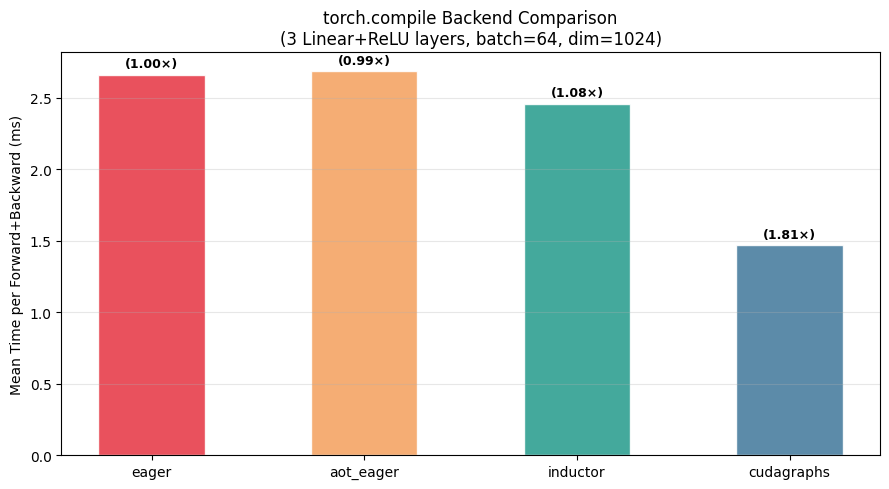

In [4]:
x = torch.randn(64, 1024, device=device)
results = {}

for name in ['eager', 'aot_eager', 'inductor', 'cudagraphs']:
    torch._dynamo.reset()
    model = SimpleNet().to(device)
    if name == 'cudagraphs':
        def _step(x_in):
            model.zero_grad()
            out = model(x_in).detach().clone().requires_grad_(True)
            out.sum().backward()
        fn = torch.compile(_step, backend='cudagraphs')
        is_cg = True
    else:
        fn = model if name == 'eager' else torch.compile(model, backend=name)
        is_cg = False
    mean, std = benchmark(fn, x, is_cudagraphs=is_cg)
    results[name] = (mean, std)
    print(f'{name:12s}  {mean:.3f} ± {std:.3f} ms')

backends = ['eager', 'aot_eager', 'inductor', 'cudagraphs']
means  = [results[n][0] for n in backends]
colors = ['#e63946', '#f4a261', '#2a9d8f', '#457b9d']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(backends, means, color=colors, alpha=0.88, width=0.5, edgecolor='white')

for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(means)*0.02,
            f'({results["eager"][0]/m:.2f}×)',
            ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Mean Time per Forward+Backward (ms)')
ax.set_title('torch.compile Backend Comparison\n(3 Linear+ReLU layers, batch=64, dim=1024)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('part1_backend_comparison.png', bbox_inches='tight')
plt.show()

### Part 1 Analysis

**Why do backends have different performance?**

The backends have different performance because they account for different types of overhead. This includes kernel launch overhead, memory bandwidth overhead, python interpretor overhead, and graph tracing overhead.

**What are the Trade-offs:**

Eager dispatches every operation individually through the Python runtime, with no fusion, no optimization.

Aot_eager applies AOTAutograd to pre-compute the backward graph, but contains tracing costs. The forward and backward graphs are captured, and the operations do not conduct kernel fusion.

Inductor is the full compilation pipeline. Inductor analyzes the FX graph and generates Triton (GPU). Key optimizations include operator fusion, memory layout selection, loop tiling that reduce memory bandwidth overhead. Slow first compile time.

Cudagraphs records all CUDA kernel launches and eliminates the kernel launch overhead. Changes in batch size or dtype will break the FX graph.

---
## Part 2: Debugging Compilation Failures

In [5]:
def problem1 ( x ) :
  # This should fail to compile
  if x . sum () > 0:
    return x * 2
  else :
    return x / 2

def problem2 ( x ) :
  # This should also have issues
  d = {}
  d ['key'] = x
  return d ['key'] * 2

def problem3 ( x ) :
  # This might have suboptimal performance
  result = 0
  for i in range (10) :
    result += ( x ** i ) . sum ()
  return result

In [6]:
import inspect

x_test = torch.randn(100, device=device)

def explain(fn):
    exp = torch._dynamo.explain(fn)(x_test)
    print(f'Graph breaks: {exp.graph_break_count}')
    if exp.break_reasons:
        print(f'Reason: {exp.break_reasons[0].reason}')
    return exp

# Problem 1
print('='*50, '\nPROBLEM 1\n' + '='*50)
print('\n[Broken]\n', inspect.getsource(problem1))
torch.compile(problem1)(x_test)
explain(problem1)
print('Dynamo cannot trace a runtime-dependent branch')

def problem1_fixed(x):
    return torch.where(x.sum() > 0, x * 2, x / 2)

print('\n[Fixed]\n', inspect.getsource(problem1_fixed))
torch.compile(problem1_fixed)(x_test)
explain(problem1_fixed)
print('Fix: torch.where replaces the Python branch with a single tensor op')

# Problem 2
print('\n' + '='*50, '\nPROBLEM 2\n' + '='*50)
print('\n[Broken]\n', inspect.getsource(problem2))
torch.compile(problem2)(x_test)
explain(problem2)
print('conditional inserts would break compilation')

def problem2_fixed(x):
    return x * 2

print('\n[Fixed]\n', inspect.getsource(problem2_fixed))
torch.compile(problem2_fixed)(x_test)
explain(problem2_fixed)
print('Fix: remove the dict and operate on the tensor directly')

# Problem 3
print('\n' + '='*50, '\nPROBLEM 3\n' + '='*50)
print('\n[Broken]\n', inspect.getsource(problem3))
torch.compile(problem3)(x_test)
exp3 = explain(problem3)
print(f'Op count: {exp3.op_count} — loop unrolled into separate graph nodes')

def problem3_fixed(x):
    return torch.stack([x ** i for i in range(10)]).sum()

print('\n[Fixed]\n', inspect.getsource(problem3_fixed))
torch.compile(problem3_fixed)(x_test)
exp3_fixed = explain(problem3_fixed)
print(f'Op count: {exp3_fixed.op_count} — collapsed into one operation')

PROBLEM 1

[Broken]
 def problem1 ( x ) :
  # This should fail to compile
  if x . sum () > 0:
    return x * 2
  else :
    return x / 2

Graph breaks: 1
Reason: generic_jump TensorVariable()
Dynamo cannot trace a runtime-dependent branch

[Fixed]
 def problem1_fixed(x):
    return torch.where(x.sum() > 0, x * 2, x / 2)

Graph breaks: 0
Fix: torch.where replaces the Python branch with a single tensor op

PROBLEM 2

[Broken]
 def problem2 ( x ) :
  # This should also have issues
  d = {}
  d ['key'] = x
  return d ['key'] * 2

Graph breaks: 0
conditional inserts would break compilation

[Fixed]
 def problem2_fixed(x):
    return x * 2

Graph breaks: 0
Fix: remove the dict and operate on the tensor directly

PROBLEM 3

[Broken]
 def problem3 ( x ) :
  # This might have suboptimal performance
  result = 0
  for i in range (10) :
    result += ( x ** i ) . sum ()
  return result

Graph breaks: 0
Op count: 20 — loop unrolled into separate graph nodes

[Fixed]
 def problem3_fixed(x):
    re

---
## Part 3: Graph Capture and Inspection

In [7]:
from torch.fx import symbolic_trace
from functorch import make_fx
import torch.nn.functional as F

log_list = []

def mixed_fn(x):
    out = x @ x.T
    out = F.relu(out @ x.T)
    out = out + x
    out = F.layer_norm(out, out.shape[-1:])
    print("Hello")
    log_list.append(out.shape)
    return out

x_test = torch.randn(10, 10, device=device)
print('Running mixed_fn:')
result = mixed_fn(x_test)
print(f'Output shape: {result.shape}')
print(f'log_list: {log_list}')


Running mixed_fn:
Hello
Output shape: torch.Size([10, 10])
log_list: [torch.Size([10, 10])]


In [8]:
print('='*50)
print('PART 3.2: Graph Capture Analysis')
print('='*50)

# torch.dynamo.explain() shows what gets captured
exp = torch._dynamo.explain(mixed_fn)(x_test)
print(f'\nGraph breaks: {exp.graph_break_count}')
print(f'Ops captured in graph: {exp.op_count}')
print(f'Break reason: {exp.break_reasons[0].reason}')

# torch.compile fullgraph=True shows exactly where it fails
print('\nfullgraph=True output:')
try:
    torch.compile(mixed_fn, fullgraph=True)(x_test)
except Exception as e:
    print(f'Error: {e}')

PART 3.2: Graph Capture Analysis
Hello

Graph breaks: 0
Ops captured in graph: 7
Break reason: Failed to trace builtin operator
  Explanation: Dynamo does not know how to trace builtin operator `print` with argument types ['str'] (has_kwargs False)
  Hint: Avoid calling builtin `print` with argument types ['str']. Consider using an equivalent alternative function/method to `print`.
  Hint: If you are attempting to call a logging function (e.g. `print`), you can try adding it to `torch._dynamo.config.reorderable_logging_functions`.
  Hint: Please report an issue to PyTorch.

  Developer debug context: builtin print [<class 'torch._dynamo.variables.constant.ConstantVariable'>] False

 For more details about this graph break, please visit: https://meta-pytorch.github.io/compile-graph-break-site/gb/gb0059.html

fullgraph=True output:
Error: Failed to trace builtin operator
  Explanation: Dynamo does not know how to trace builtin operator `print` with argument types ['str'] (has_kwargs Fals

Q1 - Which operations appear in the graph?
     Op count: 7 — matmul, matmul, relu, residual add, layer_norm

Q2 - Which operations are NOT captured?
     print() and log_list.append() — Python side-effects outside the tensor graph

Q3 - What happens to the print statement?
     Dynamo cannot trace builtin print — it causes a graph break
     and fullgraph=True refuses to compile entirely

Q4 - What happens to the list modification?
     Same as print — it mutates Python state outside the tensor graph,
     forcing Dynamo to break the graph at that line

In [9]:
from functorch import make_fx
import torch.nn.functional as F

def pure_fn(x):
    out = x @ x.T
    out = F.relu(out @ x.T)
    out = out + x
    out = F.layer_norm(out, out.shape[-1:])
    return out

x_test = torch.randn(10, 10, device=device)

traced = make_fx(pure_fn)(x_test)
traced.graph.print_tabular()

opcode         name               target                          args                            kwargs
-------------  -----------------  ------------------------------  ------------------------------  --------
placeholder    x_1                x_1                             ()                              {}
call_function  permute            aten.permute.default            (x_1, [1, 0])                   {}
call_function  mm                 aten.mm.default                 (x_1, permute)                  {}
call_function  permute_1          aten.permute.default            (x_1, [1, 0])                   {}
call_function  mm_1               aten.mm.default                 (mm, permute_1)                 {}
call_function  relu               aten.relu.default               (mm_1,)                         {}
call_function  add                aten.add.Tensor                 (relu, x_1)                     {}
call_function  native_layer_norm  aten.native_layer_norm.default  (add, [10], Non

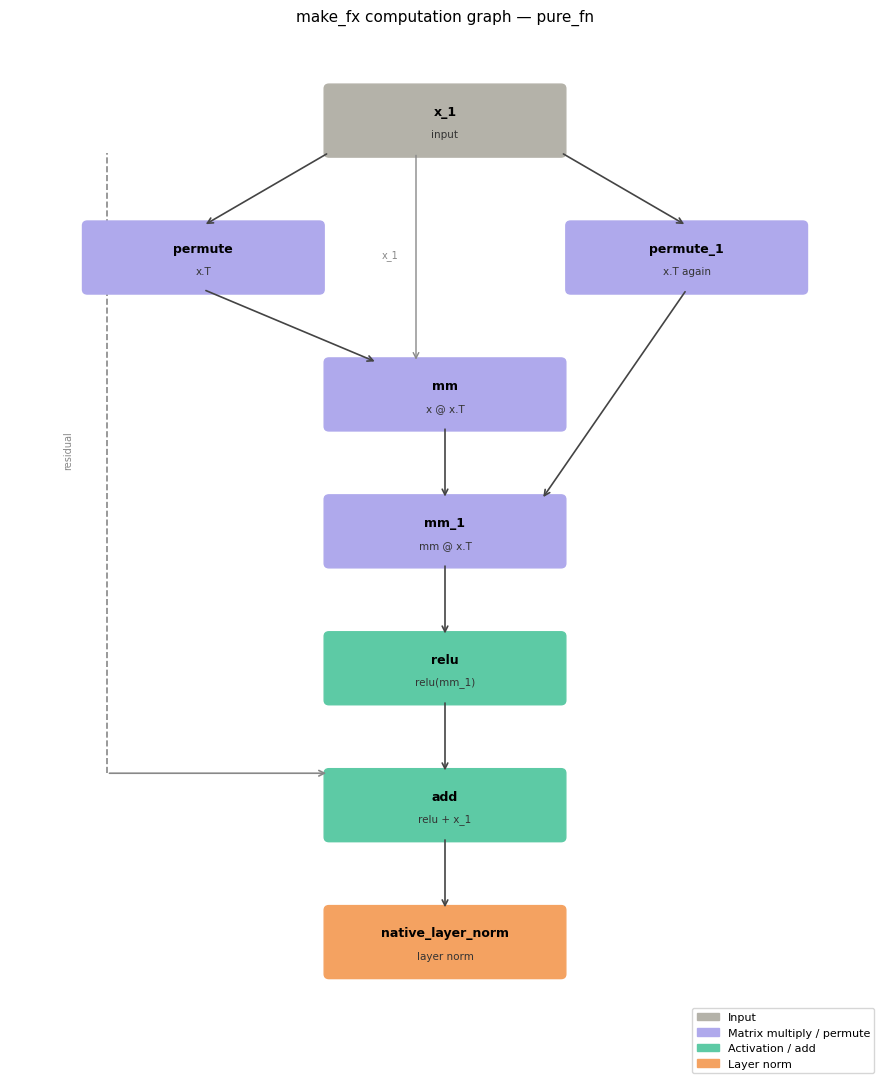

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patches as mpatch

fig, ax = plt.subplots(figsize=(9, 11))
ax.set_xlim(0, 9)
ax.set_ylim(-0.5, 11)
ax.axis('off')

# Node positions: (name, sublabel, color, x_center, y_center)
nodes = [
    ('x_1',               'input',         '#B4B2A9', 4.5, 10.0),
    ('permute',           'x.T',           '#AFA9EC', 2.0,  8.5),
    ('mm',                'x @ x.T',       '#AFA9EC', 4.5,  7.0),
    ('permute_1',         'x.T again',     '#AFA9EC', 7.0,  8.5),
    ('mm_1',              'mm @ x.T',      '#AFA9EC', 4.5,  5.5),
    ('relu',              'relu(mm_1)',     '#5DCAA5', 4.5,  4.0),
    ('add',               'relu + x_1',    '#5DCAA5', 4.5,  2.5),
    ('native_layer_norm', 'layer norm',    '#F4A261', 4.5,  1.0),
]

node_dict = {n[0]: n for n in nodes}

def draw_node(ax, name, sub, color, x, y):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x - 1.2, y - 0.35), 2.4, 0.7,
        boxstyle="round,pad=0.05", color=color, zorder=2))
    ax.text(x, y + 0.1, name, ha='center', va='center',
            fontsize=9, fontweight='bold', zorder=3)
    ax.text(x, y - 0.15, sub, ha='center', va='center',
            fontsize=7.5, color='#333', zorder=3)

for name, sub, color, x, y in nodes:
    draw_node(ax, name, sub, color, x, y)

def draw_arrow(ax, from_node, to_node, color='#444', style='->', lw=1.2, offset=(0,0)):
    _, _, _, x1, y1 = node_dict[from_node]
    _, _, _, x2, y2 = node_dict[to_node]
    x2 += offset[0]
    ax.annotate('',
        xy=(x2, y2 + 0.35),
        xytext=(x1 + offset[0], y1 - 0.35),
        arrowprops=dict(arrowstyle=style, color=color, lw=lw,
                        connectionstyle='arc3,rad=0.0'))

# x_1 -> permute (left branch)
ax.annotate('', xy=(2.0, 8.85), xytext=(3.3, 9.65),
            arrowprops=dict(arrowstyle='->', color='#444', lw=1.2))

# x_1 -> mm (direct center)
ax.annotate('', xy=(4.2, 7.35), xytext=(4.2, 9.65),
            arrowprops=dict(arrowstyle='->', color='#888', lw=1.0,
                            connectionstyle='arc3,rad=0.0'))
ax.text(3.85, 8.5, 'x_1', fontsize=7, color='#888')

# x_1 -> permute_1 (right branch)
ax.annotate('', xy=(7.0, 8.85), xytext=(5.7, 9.65),
            arrowprops=dict(arrowstyle='->', color='#444', lw=1.2))

# permute -> mm
ax.annotate('', xy=(3.8, 7.35), xytext=(2.0, 8.15),
            arrowprops=dict(arrowstyle='->', color='#444', lw=1.2))

# permute_1 -> mm_1
ax.annotate('', xy=(5.5, 5.85), xytext=(7.0, 8.15),
            arrowprops=dict(arrowstyle='->', color='#444', lw=1.2))

# mm -> mm_1
ax.annotate('', xy=(4.5, 5.85), xytext=(4.5, 6.65),
            arrowprops=dict(arrowstyle='->', color='#444', lw=1.2))

# mm_1 -> relu
ax.annotate('', xy=(4.5, 4.35), xytext=(4.5, 5.15),
            arrowprops=dict(arrowstyle='->', color='#444', lw=1.2))

# relu -> add
ax.annotate('', xy=(4.5, 2.85), xytext=(4.5, 3.65),
            arrowprops=dict(arrowstyle='->', color='#444', lw=1.2))

# x_1 -> add (residual, far left)
ax.plot([1.0, 1.0], [2.85, 9.65], '--', color='#888', lw=1.2, zorder=1)
ax.annotate('', xy=(3.3, 2.85), xytext=(1.0, 2.85),
            arrowprops=dict(arrowstyle='->', color='#888', lw=1.2))
ax.annotate('', xy=(1.0, 9.65), xytext=(3.3, 9.65),
            arrowprops=dict(arrowstyle='->', color='#888', lw=0))
ax.text(0.6, 6.2, 'residual', fontsize=7, color='#888', ha='center', rotation=90)

# add -> layer_norm
ax.annotate('', xy=(4.5, 1.35), xytext=(4.5, 2.15),
            arrowprops=dict(arrowstyle='->', color='#444', lw=1.2))

ax.legend(handles=[
    mpatches.Patch(color='#B4B2A9', label='Input'),
    mpatches.Patch(color='#AFA9EC', label='Matrix multiply / permute'),
    mpatches.Patch(color='#5DCAA5', label='Activation / add'),
    mpatches.Patch(color='#F4A261', label='Layer norm'),
], loc='lower right', fontsize=8)

ax.set_title('make_fx computation graph — pure_fn', fontsize=11)
plt.tight_layout()
plt.savefig('part3_graph.png', dpi=150, bbox_inches='tight')
plt.show()